# 循环神经网络的简洁实现
:label:`sec_rnn-concise`

虽然 :numref:`sec_rnn_scratch`
对了解循环神经网络的实现方式具有指导意义，但并不方便。
本节将展示如何使用深度学习框架的高级API提供的函数更有效地实现相同的语言模型。
我们仍然从读取时光机器数据集开始。


In [1]:
import torch
from torch import nn
from torch.nn import functional as F

# from d2l import torch as d2l
import os
import sys

sys.path.append("..")
import d2l.d2l as d2l

os.chdir(".")
print("Working directory:", os.getcwd())

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)


Working directory: /data/home/yyx/Project/Deep2AI/d2l-zh/pytorch/chapter_recurrent-neural-networks


## [**定义模型**]

高级API提供了循环神经网络的实现。
我们构造一个具有256个隐藏单元的单隐藏层的循环神经网络层`rnn_layer`。
事实上，我们还没有讨论多层循环神经网络的意义（这将在 :numref:`sec_deep_rnn`中介绍）。
现在仅需要将多层理解为一层循环神经网络的输出被用作下一层循环神经网络的输入就足够了。


In [2]:
num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)

我们(**使用张量来初始化隐状态**)，它的形状是（隐藏层数，批量大小，隐藏单元数）。


In [3]:
state = torch.zeros((1, batch_size, num_hiddens))
state.shape


torch.Size([1, 32, 256])

[**通过一个隐状态和一个输入，我们就可以用更新后的隐状态计算输出。**]
需要强调的是，`rnn_layer`的“输出”（`Y`）不涉及输出层的计算：
它是指每个时间步的隐状态，这些隐状态可以用作后续输出层的输入。


In [4]:
X = torch.rand(size=(num_steps, batch_size, len(vocab)))
Y, state_new = rnn_layer(X, state)
Y.shape, state_new.shape


(torch.Size([35, 32, 256]), torch.Size([1, 32, 256]))

与 :numref:`sec_rnn_scratch`类似，
[**我们为一个完整的循环神经网络模型定义了一个`RNNModel`类**]。
注意，`rnn_layer`只包含隐藏的循环层，我们还需要创建一个单独的输出层。


In [5]:
# @save
class RNNModel(nn.Module):
    """循环神经网络模型"""

    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        # 如果RNN是双向的（之后将介绍），num_directions应该是2，否则应该是1
        if not self.rnn.bidirectional:
            self.num_directions = 1
            self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # 全连接层首先将Y的形状改为(时间步数*批量大小,隐藏单元数)
        # 它的输出形状是(时间步数*批量大小,词表大小)。
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # nn.GRU以张量作为隐状态
            return torch.zeros(
                (
                    self.num_directions * self.rnn.num_layers,
                    batch_size,
                    self.num_hiddens,
                ),
                device=device,
            )
        else:
            # nn.LSTM以元组作为隐状态
            return (
                torch.zeros(
                    (
                        self.num_directions * self.rnn.num_layers,
                        batch_size,
                        self.num_hiddens,
                    ),
                    device=device,
                ),
                torch.zeros(
                    (
                        self.num_directions * self.rnn.num_layers,
                        batch_size,
                        self.num_hiddens,
                    ),
                    device=device,
                ),
            )


## 训练与预测

在训练模型之前，让我们[**基于一个具有随机权重的模型进行预测**]。


In [6]:
device = d2l.try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
d2l.predict_ch8("time traveller", 10, net, vocab, device)


'time travellerjjpxgjjpjj'

很明显，这种模型根本不能输出好的结果。
接下来，我们使用 :numref:`sec_rnn_scratch`中
定义的超参数调用`train_ch8`，并且[**使用高级API训练模型**]。


/data/home/yyx/Project/Deep2AI/d2l-zh/pytorch/chapter_recurrent-neural-networks/../d2l/d2l.py:253: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


time travellere the the the the the the the the the the the the 


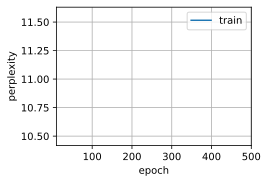

time traveller and the the the the the the the the the the the t


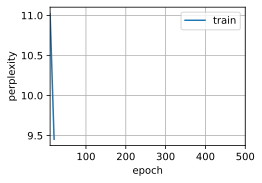

time traveller and he the the the the the the the the the the th


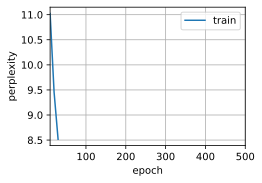

time traveller andithe the the the the the the the the the the t


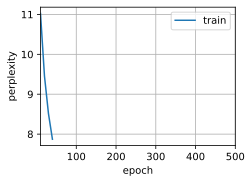

time traveller the the the the the the the the the the the the t


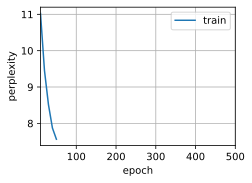

time traveller ace and the time tre the the the the the the the 


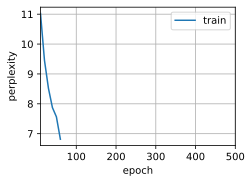

time travellerthe thave atout iont and and the thas ars and at a


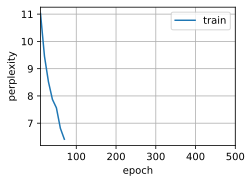

time traveller challight reas in the time s ancall the t ane the


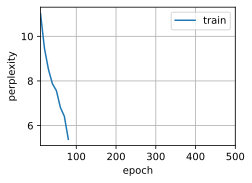

time travelleric toreat of ravell as of spacente in aspor a dong


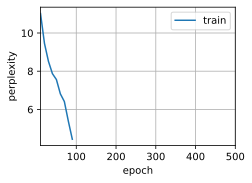

time travellerth s an and bo is and ffont sige tin whing t an wh


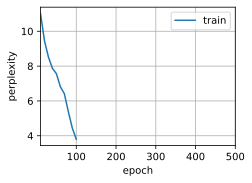

time traveller s the onder and ha dimens on ple has il the teree


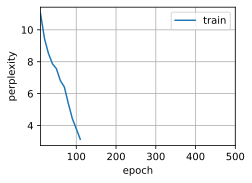

time traveller but no thisknt time alling these is ald hat in an


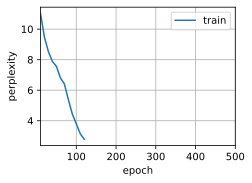

time traveller hat andided and inat exiche on viment a fired and


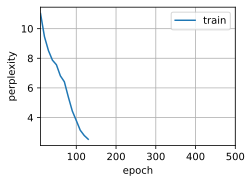

time traveller proveed acon lo got on wom doneth or dome as whis


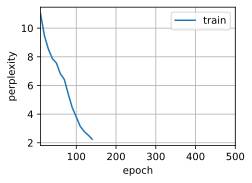

time travellerit tou an surmale cats taly lare rove about in and


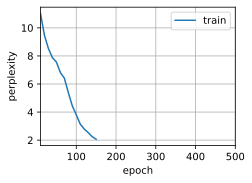

time traveller ffterte tlanethes at shas it s tily there tere tl


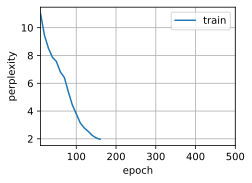

time traveller pot and ane dimensions as move about in timethat 


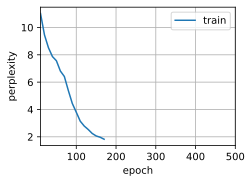

time traveller sccente ib the e that buthe sond mowking this int


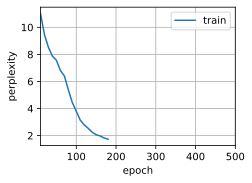

time travellerit sough aly caredeant or sofis ans gow if alary t


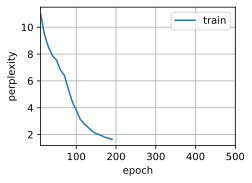

time traveller art mantt trect in thing ti bont regree allotrect


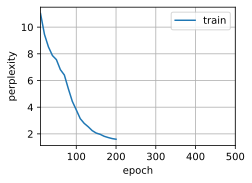

time travellerit s afaid the gadilanspor the inding to sceptonot


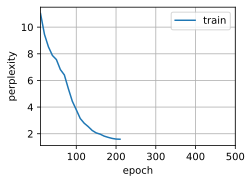

time traveller percams d ane drad the thith lastion im fouthe ra


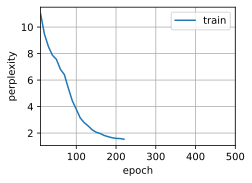

time travellerit s ancinstay i go thi know s in tourse and sivel


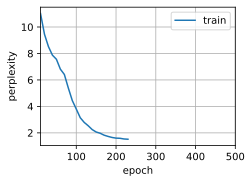

time travelleric sore so ling terallotrers of has ie tlaysighid 


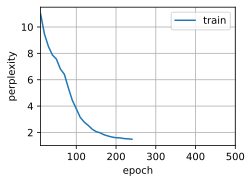

time traveller but now you begin to seetli at move it andthis do


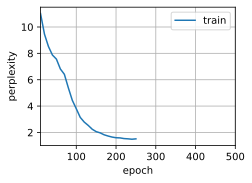

time traveller por and four and simelare sure waldenssould fore 


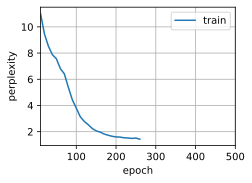

time travellericctiancoour a teat there itneed fhor aid there is


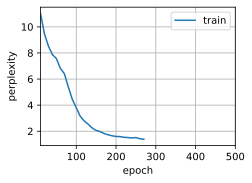

time travellerit s against reaton is to she llous the andmants a


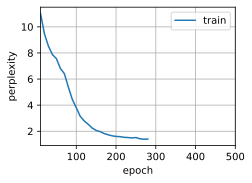

time traveller pe cam than to may in tay it in aid the vely onov


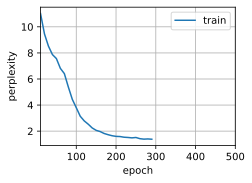

time travellerit s against reason said the time travellerit s ag


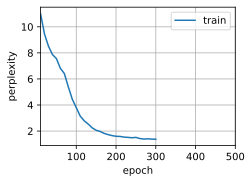

time traveller hot sas lither sicentto mone ablict ool master of


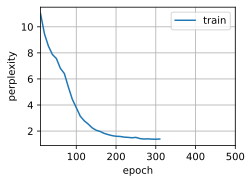

time traveller but now you bogk foomed at us in time ascinly in 


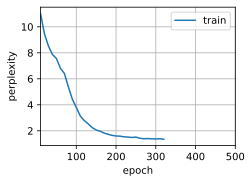

time traveller proceeded anyreal ixinest laid the time traveller


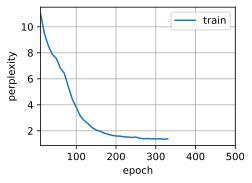

time travellerit s against reavon some that upre wo k ond nilwer


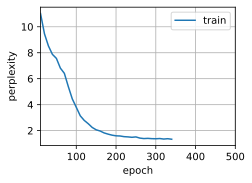

time travellerit s against geason thit is accepolse thing ceat t


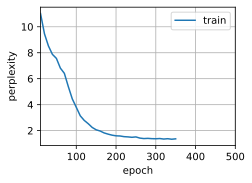

time traveller paccant ub tle youncimenithing the mithel than as


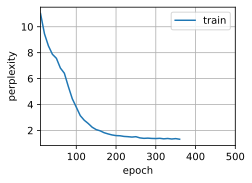

time traveller hald at rean thrpe is ore ger onjumt at the llyou


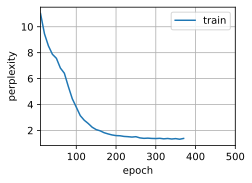

time travelleric sise time braccuberabais a listedsttrof it foun


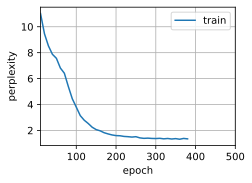

time traveller after the packer abre ard whom the prome soug sig


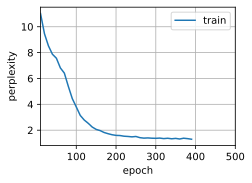

time traveller proceeded anyreal body must have erendof by che a


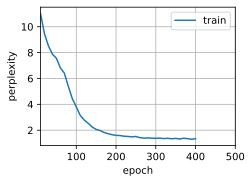

time traveller held in his hand was a glitteringmetallic from th


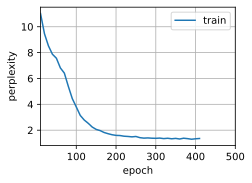

time traveller held in his hand was have thement and his yonntwa


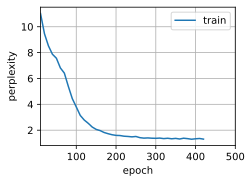

time travellerit s against reason said the medical man there are


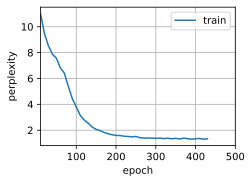

time travelleryou can show beall spall chaccimen thing to a sour


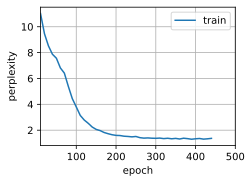

time traveller proceeded anyreal body wust havele the beccnof co


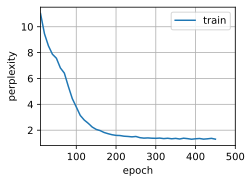

time travellerit s against reason said the medical man there are


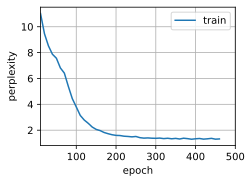

time travellerit s agree monn wo deat of hrewsond af frewe wacco


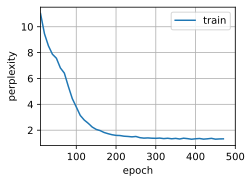

time traveller he saghes to the others but somephilosophical peo


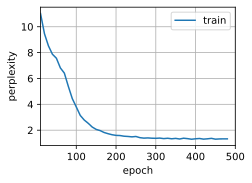

time traveller proceeded anyreal body must have extension in fou


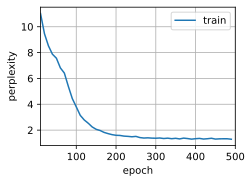

time traveller proceeded andres about ian ancuntedy tack there w


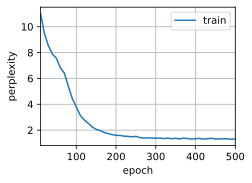

困惑度 1.3, 481301.2 词元/秒 cuda:0
time traveller proceeded andres about ian ancuntedy tack there w
traveller but now you thaten thisgisanofo mads ge move arou


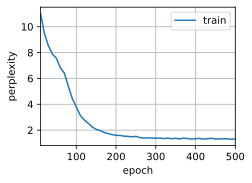

In [7]:
num_epochs, lr = 500, 1
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, device)


与上一节相比，由于深度学习框架的高级API对代码进行了更多的优化，
该模型在较短的时间内达到了较低的困惑度。

## 小结

* 深度学习框架的高级API提供了循环神经网络层的实现。
* 高级API的循环神经网络层返回一个输出和一个更新后的隐状态，我们还需要计算整个模型的输出层。
* 相比从零开始实现的循环神经网络，使用高级API实现可以加速训练。

## 练习

1. 尝试使用高级API，能使循环神经网络模型过拟合吗？
1. 如果在循环神经网络模型中增加隐藏层的数量会发生什么？能使模型正常工作吗？
1. 尝试使用循环神经网络实现 :numref:`sec_sequence`的自回归模型。


[Discussions](https://discuss.d2l.ai/t/2106)
